In [1]:
import pandas as pd
import datetime as dt
from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
def replace_timestamps_with_step_times(df):
    step_names = ["prefetch", "fasterq_dump", "salmon", "deseq2_salmon", "star", "deseq2_star"]
    for step_name in step_names:
        if step_name+"_start_time" in df.columns:
            start_times = (pd.to_datetime(df[f"{step_name}_start_time"]) - dt.datetime(1970,1,1)).dt.total_seconds()
            end_times = (pd.to_datetime(df[f"{step_name}_end_time"]) - dt.datetime(1970,1,1)).dt.total_seconds()
            df[f"{step_name} [s]"] = end_times - start_times

    return df

In [3]:
df_fargate = replace_timestamps_with_step_times(pd.read_csv("data/STAR_fargate_1k.csv", index_col=0))

In [4]:
df_ec2_full = pd.read_csv("data/STAR_EC2_7k.csv", index_col=0)
df_ec2_full = replace_timestamps_with_step_times(df_ec2_full)
df_ec2 = df_ec2_full[df_ec2_full["SRR_id"].isin(set(df_fargate["SRR_id"]))]

In [5]:
print(f"Fargate total pipeline execution time: {((df_fargate['star [s]'] + df_fargate['prefetch [s]'] + df_fargate['fasterq_dump [s]'] + df_fargate['deseq2_star [s]']).sum() / 3600):.2f} h")
print(f"EC2 R7a total pipeline execution time: {((df_ec2['star [s]'] + df_ec2['prefetch [s]'] + df_ec2['fasterq_dump [s]'] + df_ec2['deseq2_star [s]']).sum() / 3600):.2f} h")

Fargate total pipeline execution time: 207.44 h
EC2 R7a total pipeline execution time: 138.60 h


In [6]:
print(f"Fargate total STAR execution time: {(df_fargate['star [s]'].sum() / 3600):.2f} h")
print(f"EC2 R7a total STAR execution time: {(df_ec2['star [s]'].sum() / 3600):.2f} h")

Fargate total STAR execution time: 176.42 h
EC2 R7a total STAR execution time: 108.22 h


In [7]:
print(f"Fargate mean STAR execution time: {(df_fargate['star [s]'].mean()):.2f} s")
print(f"EC2 R7a mean STAR execution time: {(df_ec2['star [s]'].mean()):.2f} s")

Fargate mean STAR execution time: 644.79 s
EC2 R7a mean STAR execution time: 391.54 s


In [8]:
def non_star_steps_percent(df):
    return ((df["prefetch [s]"] + df["fasterq_dump [s]"] + df["deseq2_star [s]"]) / (df["prefetch [s]"] + df["fasterq_dump [s]"] + df["star [s]"] + df["deseq2_star [s]"])).mean()

print(f"Fargate non-STAR steps total execution time percent : {non_star_steps_percent(df_fargate):.2f} %")
print(f"EC2 R7a non-STAR steps total execution time percent : {non_star_steps_percent(df_ec2):.2f} %")

Fargate non-STAR steps total execution time percent : 0.21 %
EC2 R7a non-STAR steps total execution time percent : 0.26 %


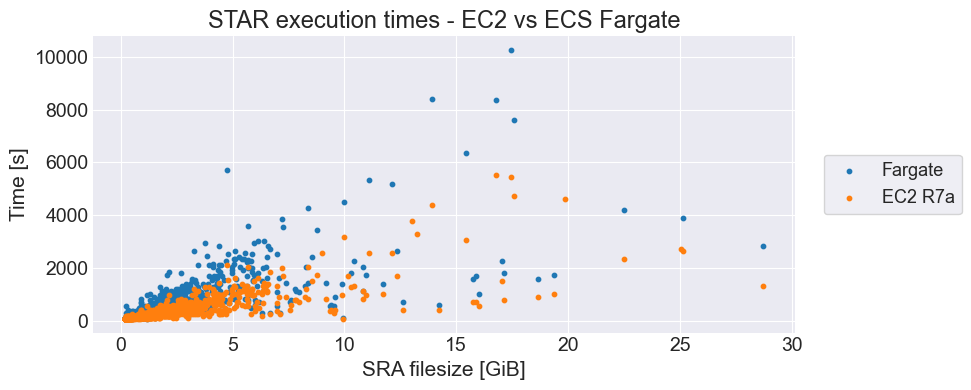

In [9]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

ax.scatter(df_fargate['SRR_filesize_bytes'] / 1024**3, df_fargate['star [s]'], label='Fargate', s=10)
ax.scatter(df_ec2['SRR_filesize_bytes'] / 1024**3, df_ec2['star [s]'], label='EC2 R7a', s=10)

ax.set_xlabel('SRA filesize [GiB]', fontsize=15)
ax.set_ylabel('Time [s]', fontsize=15)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_title('STAR execution times - EC2 vs ECS Fargate', fontsize=17)

ax.legend(fontsize=13, bbox_to_anchor=(1.25, 0.5), frameon=True, loc='center right')
plt.tight_layout()
plt.savefig('plots/STAR_exec_times_ec2_vs_ecs.pdf', bbox_inches='tight')
plt.show()

In [10]:
df_fargate.groupby("instance_id")["cpu_model"].unique().value_counts()

cpu_model
[AMD EPYC 7R13 Processor]                           9
[Intel(R) Xeon(R) Platinum 8259CL CPU @ 2.50GHz]    7
[Intel(R) Xeon(R) Platinum 8175M CPU @ 2.50GHz]     4
Name: count, dtype: int64

In [11]:
df_fargate["error_type"].value_counts()

error_type
Early stopping          131
STAR error               11
Invalid library type      4
Name: count, dtype: int64